In [3]:
import os
import yfinance as yf
import pandas as pd

# 1. Define our target data parameters
ticker_symbol = "AAPL"  # Feel free to change this to any stock ticker
start_date = "2021-01-01"
end_date = "2026-01-01"

print(f"Reaching out to Yahoo Finance for {ticker_symbol} data...")

# 2. Download the historical data
stock_data = yf.download(ticker_symbol, start=start_date, end=end_date)

# 3. Create a 'data' folder and save the CSV
os.makedirs('data', exist_ok=True)
target_path = os.path.join('data', 'historical_prices.csv')
stock_data.to_csv(target_path)

print(f"SUCCESS: {len(stock_data)} days of market data saved to {target_path}")


#ohh so name decided by path.join
#then created and written by .to_csv right ??----YES

Reaching out to Yahoo Finance for AAPL data...


[*********************100%***********************]  1 of 1 completed

SUCCESS: 1255 days of market data saved to data/historical_prices.csv


In [4]:
# Load the CSV we just saved and look at the top 5 rows
df = pd.read_csv('data/historical_prices.csv')

# Display the clean dataframe matrix
df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
1,Date,NaN,NaN,NaN,NaN,NaN
2,2021-01-04,125.7408447265625,129.8217592553949,123.16597863459702,129.73431458165692,143301900
3,2021-01-05,127.29547882080078,128.00479186519019,124.78862757117713,125.23559175221487,97664900
4,2021-01-06,123.01050567626953,127.33433916722099,122.79674215546176,124.09875295807365,155088000


In [5]:
import pandas as pd

# 1. Load the CSV
# We use skiprows=[1, 2] to completely ignore the 'Ticker' and 'Date' rows.
# We use index_col=0 to tell Pandas: "Make the very first column the index."
df = pd.read_csv('data/historical_prices.csv', skiprows=[1, 2], index_col=0, parse_dates=True)

# 2. Rename the index
# Because that first column was labeled 'Price' in the CSV, Pandas named our index 'Price'.
# We want it to be called 'Date' so our code is readable.
df.index.name = 'Date'

# 3. Print the result
print("Raw Data Loaded:")
print(df.head())

Raw Data Loaded:
                 Close        High         Low        Open     Volume
Date                                                                 
2021-01-04  125.740845  129.821759  123.165979  129.734315  143301900
2021-01-05  127.295479  128.004792  124.788628  125.235592   97664900
2021-01-06  123.010506  127.334339  122.796742  124.098753  155088000
2021-01-07  127.208038  127.897914  124.234801  124.720624  109578200
2021-01-08  128.305984  128.869542  126.537580  128.675200  105158200


In [6]:
# Calculate the Fast Line (10-Day Moving Average)
df['SMA_10'] = df['Close'].rolling(window=10).mean()

# Calculate the Slow Line (50-Day Moving Average)
df['SMA_50'] = df['Close'].rolling(window=50).mean()

# Display the specific columns we care about, looking at the top 60 rows
print("\nCalculated Moving Averages:")
print(df[['Close', 'SMA_10', 'SMA_50']].head(60))


Calculated Moving Averages:
                 Close      SMA_10      SMA_50
Date                                          
2021-01-04  125.740845         NaN         NaN
2021-01-05  127.295479         NaN         NaN
2021-01-06  123.010506         NaN         NaN
2021-01-07  127.208038         NaN         NaN
2021-01-08  128.305984         NaN         NaN
2021-01-11  125.323044         NaN         NaN
2021-01-12  125.148148         NaN         NaN
2021-01-13  127.178864         NaN         NaN
2021-01-14  125.255043         NaN         NaN
2021-01-15  123.535202  125.800115         NaN
2021-01-19  124.205650  125.646596         NaN
2021-01-20  128.286530  125.745701         NaN
2021-01-21  132.989319  126.743582         NaN
2021-01-22  135.126968  127.535475         NaN
2021-01-25  138.867828  128.591660         NaN
2021-01-26  139.100998  129.969455         NaN
2021-01-27  138.032196  131.257860         NaN
2021-01-28  133.203094  131.860283         NaN
2021-01-29  128.218597  132.156

In [7]:
# Step 3: Why do Quants use this? (The Alpha)
# Looking at a raw matrix of numbers can be abstract. Why do we care about a 10-day average versus a 50-day average?

# Raw daily stock prices are chaotic and filled with "noise" (random daily panic or hype). Moving averages act as a mathematical filter to reveal the true underlying trend. Play with this interactive visualizer to see exactly how your code is smoothing out the data:



# The Trading Logic you just built the foundation for:

# The 10-Day (Fast Line): Reacts very quickly to what traders are doing right now.

# The 50-Day (Slow Line): Represents the long-term, established trend of the stock.

# The Signal: When the Fast Line crosses above the Slow Line, it means a sudden surge of momentum is overpowering the long-term trend. This is a classic Buy Signal.

In [8]:
import numpy as np

# 1. Clean the matrix: Drop the first 49 days that have 'NaN' (missing) values 
# because the 50-day average couldn't be calculated yet.
df = df.dropna()

# 2. Create a new column called 'Signal' and fill it with 0s (Hold)
df['Signal'] = 0

# 3. The Vectorized Logic: 
# If the Fast Line is greater than the Slow Line, change the Signal to 1 (BUY)
df.loc[df['SMA_10'] > df['SMA_50'], 'Signal'] = 1

# If the Fast Line is less than the Slow Line, change the Signal to -1 (SELL)
df.loc[df['SMA_10'] < df['SMA_50'], 'Signal'] = -1

# Let's check how many times we are holding a Buy vs a Sell position
print("Total Days in each position:")
print(df['Signal'].value_counts())      

Total Days in each position:
Signal
 1    700
-1    506
Name: count, dtype: int64


In [9]:
df

,Close,High,Low,Open,Volume,SMA_10,SMA_50,Signal
Date,,,,,,,,
2021-03-16,122.192047,123.797662,121.364914,122.318547,115227900,118.094329,126.283383,-1
2021-03-17,121.403847,122.474254,119.048941,120.712947,111932600,118.357066,126.196643,-1
2021-03-18,117.287605,119.866319,117.083255,119.574386,121229700,118.395988,125.996485,-1
2021-03-19,116.762131,118.163395,116.460472,116.674555,185549500,118.256831,125.871518,-1
2021-03-22,120.070694,120.537785,117.024897,117.093013,111912300,118.940921,125.728771,-1
...,...,...,...,...,...,...,...,...
2025-12-24,273.302216,274.919206,271.695216,271.834940,17910600,273.478900,270.452087,1
2025-12-26,272.892975,274.859323,272.353968,273.651575,21521800,273.016757,270.937215,1
2025-12-29,273.252350,273.851213,271.844961,272.184327,23715200,272.565598,271.467224,1


In [10]:
# suppose 50 d is 100 and 10 d is 101 we buy
# then when 50 d is 90 and 10d is 89 we sell
# we had a loss of 12 here
#THIS IS THE FAMOUS 'WHIPSAW EFFECT'


# Exactly. Your math is 100% correct. You bought at ~101, you sold at ~89, and you locked in a painful $12 loss.

# You have just successfully reverse-engineered the exact reason why Trend Following strategies are terrifying for normal people to trade.

# In the hedge fund world, the scenario you just described is called a "False Breakout" or a "Whipsaw." If you are a Quant running this algorithm, you have to look your boss in the eye and explain why the computer just lost $12. And here is exactly what you would say to defend your algorithm:

# The Quant's Defense: "Death by a thousand cuts, but catching the rocket."
# A Moving Average strategy does not try to win every trade. In fact, a good moving average algorithm usually loses 60% of the time. It will take that $12 loss over, and over, and over again in a sideways, choppy market.

# But why do multi-billion dollar funds still use variations of this?

# Because of what happens when the math goes right.

# The 50-day is 100, the 10-day is 101. The algo BUYS.

# The stock doesn't crash this time. Instead, a massive Bull Market starts.

# The stock goes to 120... 150... 200... 250.

# Because the 10-day stays safely above the 50-day the entire time, the algorithm never sells. It rides the rocket.

# Finally, the market crashes. At $230, the 10-day drops below the 50-day. The algo SELLs.

# The final math:

# You took five $12 losses in a row during the choppy months (Lost $60).

# You caught one massive trend and made $130.

# Net Profit: +$70.

In [11]:
# 1. Calculate the daily percentage change of the stock itself (Buy and Hold strategy)
# .pct_change() calculates how much the price jumped or dropped compared to yesterday
df['Stock_Returns'] = df['Close'].pct_change()

# 2. Calculate OUR Algorithm's returns!
# We shift the signal down by 1 day. Why? Because if the signal says 'BUY' at the very 
# end of today, we don't make money until tomorrow's price movement!
df['Algo_Returns'] = df['Signal'].shift(1) * df['Stock_Returns']

# 3. Calculate the cumulative compound growth of $1 invested in both strategies
# (Don't worry about the complex math here, it just adds up all the daily percentages)
df['Stock_Cumulative'] = (1 + df['Stock_Returns']).cumprod()
df['Algo_Cumulative'] = (1 + df['Algo_Returns']).cumprod()

# Print the final score!
print("Final Output:")
print(df[['Stock_Cumulative', 'Algo_Cumulative']].tail())

Final Output:
            Stock_Cumulative  Algo_Cumulative
Date                                         
2025-12-24          2.236661         0.939984
2025-12-26          2.233312         0.938576
2025-12-29          2.236253         0.939812
2025-12-30          2.230698         0.937478
2025-12-31          2.220732         0.933289


In [12]:
df

#TELL ME IF WE GAVE SG OF SELL AT 1 DOLLAR

# STOCK GOES 1.02 DOLLAR

# WHY ARE WE COMPOUNDING LOSS OF 0..02

# WE DIDNT LOSE OUR MONEY NAA WE JUST LOST A OPP TO CREATE MORE MONEY SO HOW IT IS A LOSS

# This is a brilliant question. Your logic is perfectly sound, but you just uncovered a massive difference between normal investing and quantitative trading.

# If our algorithm just sold our shares and held cash, you would be 100% correct. We wouldn't lose a single penny; we would just miss out on the profit.

# But in our code, our signal wasn't 0 (Hold Cash). Our signal was -1.

# In finance, a -1 signal means you are doing something called Short Selling. You aren't just sitting on the sidelines; you are actively betting that the stock will go down.

# The Mechanics of a Short Sell (Why you actually lose money):
# Imagine Apple is at $1.00. Our algorithm calculates the 10-day has crossed below the 50-day and triggers a -1 (SELL). Here is exactly what happens in your brokerage account in milliseconds:

# The Borrow: You don't own any Apple stock right now. So, your algorithm automatically borrows 1 share of Apple from your broker.

# The Sale: It immediately sells that borrowed share to a stranger for $1.00. You now have $1.00 cash in your hand, but you owe your broker 1 share.

# The Trap: The stock price suddenly goes up to $1.02.

# The Buy-Back: You have to give the broker their share back eventually. To do that, you are forced to go out into the market and buy 1 share. But the price is now $1.02!

# The Math: You gained $1.00 when you sold it. You had to spend $1.02 to buy it back.
# $1.00 - $1.02 = -$0.02

# You didn't just miss an opportunity. Your bank account is physically lighter by 2 cents.



,Close,High,Low,Open,Volume,SMA_10,SMA_50,Signal,Stock_Returns,Algo_Returns,Stock_Cumulative,Algo_Cumulative
Date,,,,,,,,,,,,
2021-03-16,122.192047,123.797662,121.364914,122.318547,115227900,118.094329,126.283383,-1,NaN,NaN,NaN,NaN
2021-03-17,121.403847,122.474254,119.048941,120.712947,111932600,118.357066,126.196643,-1,-0.006451,0.006451,0.993549,1.006451
2021-03-18,117.287605,119.866319,117.083255,119.574386,121229700,118.395988,125.996485,-1,-0.033905,0.033905,0.959863,1.040575
2021-03-19,116.762131,118.163395,116.460472,116.674555,185549500,118.256831,125.871518,-1,-0.004480,0.004480,0.955562,1.045237
2021-03-22,120.070694,120.537785,117.024897,117.093013,111912300,118.940921,125.728771,-1,0.028336,-0.028336,0.982639,1.015619
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-24,273.302216,274.919206,271.695216,271.834940,17910600,273.478900,270.452087,1,0.005324,0.005324,2.236661,0.939984
2025-12-26,272.892975,274.859323,272.353968,273.651575,21521800,273.016757,270.937215,1,-0.001497,-0.001497,2.233312,0.938576
2025-12-29,273.252350,273.851213,271.844961,272.184327,23715200,272.565598,271.467224,1,0.001317,0.001317,2.236253,0.939812


In [15]:
# If you gave the algorithm $1.00 It gave you back $0.93.
# If you just bought the stock and did absolutely nothing  You would have $2.22.
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 3.8 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 4.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 3.9 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


Matplotlib is building the font cache; this may take a moment.


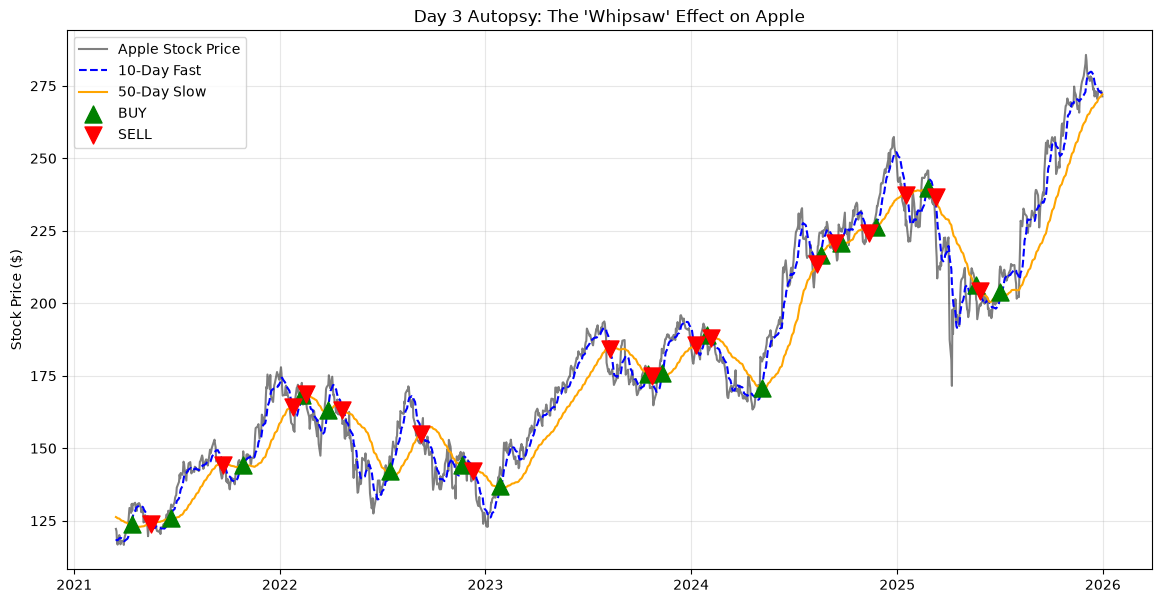

In [16]:
import matplotlib.pyplot as plt

# 1. Set up the canvas (14 inches wide, 7 inches tall
plt.figure(figsize=(14, 7))

# 2. Draw the main lines: Stock Price, Fast Line, and Slow Line
# alpha=0.5 makes the stock price slightly transparent so the MAs stand out
plt.plot(df.index, df['Close'],  label='Apple Stock Price', color='black', alpha=0.5)
plt.plot(df.index, df['SMA_10'], label='10-Day Fast', color='blue', linestyle='--')
plt.plot(df.index, df['SMA_50'], label='50-Day Slow', color='orange')

# 3. Edge Detection: Find the exact day the signal FLIPPE
# .diff() subtracts yesterday's signal from today's signal. 
# If it goes from -1 to 1, the difference is +2 (A state change!)
df['State_Change'] = df['Signal'].diff()

# 4. Paint the Buy Arrows (Green, pointing UP)
# Filter for days where the state change is greater than 0
buy_signals = df[df['State_Change'] > 0]
plt.scatter(buy_signals.index, buy_signals['SMA_10'], marker='^', color='green', s=150, label='BUY', zorder=5)

# 5. Paint the Sell Arrows (Red, pointing DOWN)
# Filter for days where the state change is less than 0
sell_signals = df[df['State_Change'] < 0]
plt.scatter(sell_signals.index, sell_signals['SMA_10'], marker='v', color='red', s=150, label='SELL', zorder=5)

# 6. Make it look professional (Titles, Grids, Legends)
plt.title("Day 3 Autopsy: The 'Whipsaw' Effect on Apple")
plt.ylabel("Stock Price ($)")
plt.legend()
plt.grid(True, alpha=0.3)

# Render the final image!
plt.show()

In [23]:
import sqlite3

✅ SYSTEM READY: Data loaded successfully from data/historical_prices.csv
✅ LOGIC SET: Using 10-day and 50-day moving averages.
✅ MATH COMPLETE: Algo Multiplier: $0.93 | Buy & Hold: $2.16


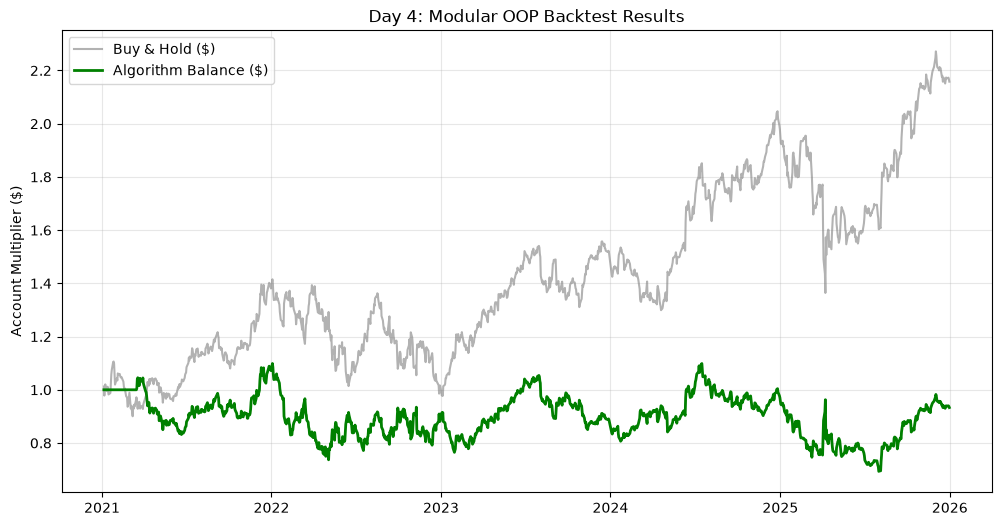

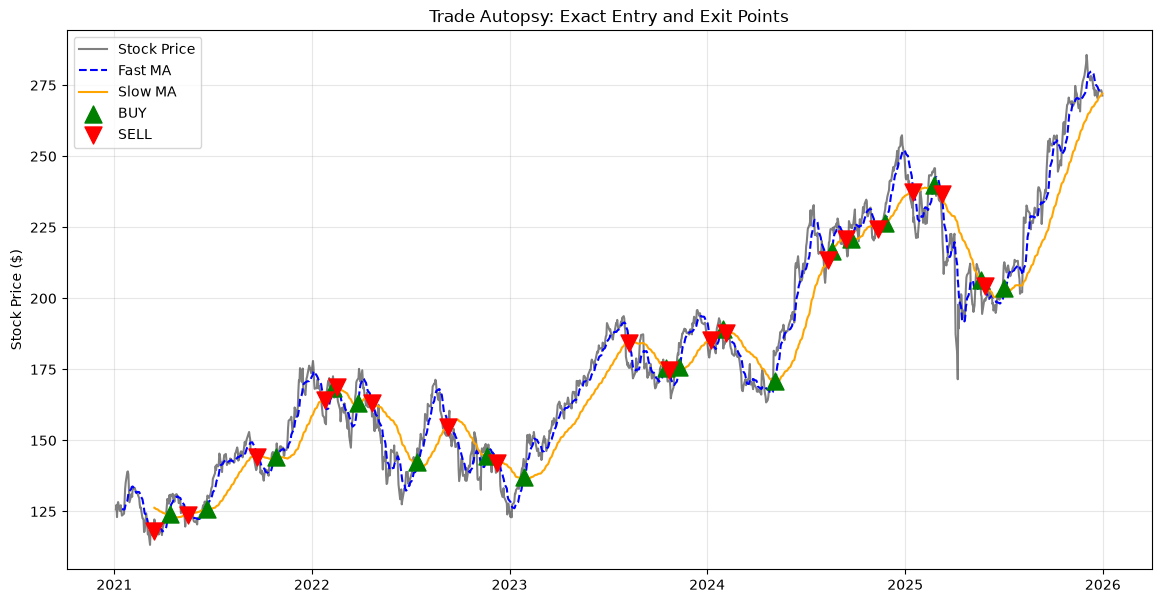

✅ LEDGER READY: Connected to trading_ledger.db and verified schema.
✅ LEDGER UPDATED: Permanently saved 36 trades for AAPL.


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ==========================================
# DAY 4: THE OOP TRADING ENGINE
# ==========================================    

class BacktestEngine:
    def __init__(self, filepath):
        """1. The Constructor: Initializes the engine and loads the data."""
        if not os.path.exists(filepath):
            raise FileNotFoundError(f"Cannot find {filepath}. Did you run the Day 1 download code?")
            
        self.df = pd.read_csv(filepath,header=0,skiprows=[1,2])
        self.df.rename(columns={'Price': 'Date'}, inplace=True)

        self.df['Date'] = pd.to_datetime(self.df['Date'])
        self.df.set_index('Date', inplace=True)
        print(f"✅ SYSTEM READY: Data loaded successfully from {filepath}")

    def generate_signals(self, fast_window=10, slow_window=50):
        """2. The Logic Module: Calculates MAs and generates Buy/Sell signals."""
        self.df['SMA_Fast'] = self.df['Close'].rolling(window=fast_window).mean()
        self.df['SMA_Slow'] = self.df['Close'].rolling(window=slow_window).mean()
        self.df['Signal'] = 0
        # The Day 2 State Machine
        # 2. Use .loc to target specific rows and update the Signal
        self.df.loc[self.df['SMA_Fast'] > self.df['SMA_Slow'], 'Signal'] = 1
        self.df.loc[self.df['SMA_Fast'] <= self.df['SMA_Slow'], 'Signal'] = -1
        
        print(f"✅ LOGIC SET: Using {fast_window}-day and {slow_window}-day moving averages.")

    def run_backtest(self):
        """3. The Math Module: Calculates compounding returns (The Snowball)."""
        self.df['Stock_Returns'] = self.df['Close'].pct_change()
        
        # Shift signal to prevent lookahead bias!
        self.df['Algo_Returns'] = self.df['Signal'].shift(1) * self.df['Stock_Returns']
        
        # Compounding math
        self.df['Stock_Cumulative'] = (1 + self.df['Stock_Returns']).cumprod()
        self.df['Algo_Cumulative'] = (1 + self.df['Algo_Returns']).cumprod()
        
        final_algo = self.df['Algo_Cumulative'].iloc[-1]
        final_stock = self.df['Stock_Cumulative'].iloc[-1]
        print(f"✅ MATH COMPLETE: Algo Multiplier: ${final_algo:.2f} | Buy & Hold: ${final_stock:.2f}")

    def plot_account_growth(self):
        """4. The UI Module: Visualizes the final account balances over time."""
        plt.figure(figsize=(12, 6))
        plt.plot(self.df.index, self.df['Stock_Cumulative'], label='Buy & Hold ($)', color='gray', alpha=0.6)
        plt.plot(self.df.index, self.df['Algo_Cumulative'], label='Algorithm Balance ($)', color='green', linewidth=2)
        
        plt.title("Day 4: Modular OOP Backtest Results")
        plt.ylabel("Account Multiplier ($)")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()


    def plot_trade_autopsy(self):
        """5. The Debug Module: Shows exact buy/sell execution points."""
        plt.figure(figsize=(14, 7))
        
        # Plot the main lines
        plt.plot(self.df.index, self.df['Close'], label='Stock Price', color='black', alpha=0.5)
        plt.plot(self.df.index, self.df['SMA_Fast'], label='Fast MA', color='blue', linestyle='--')
        plt.plot(self.df.index, self.df['SMA_Slow'], label='Slow MA', color='orange')

        # Find the flips
        state_change = self.df['Signal'].diff()
        buy_signals = self.df[state_change > 0]
        sell_signals = self.df[state_change < 0]

        # Paint the arrows
        plt.scatter(buy_signals.index, buy_signals['SMA_Fast'], marker='^', color='green', s=150, label='BUY', zorder=5)
        plt.scatter(sell_signals.index, sell_signals['SMA_Fast'], marker='v', color='red', s=150, label='SELL', zorder=5)

        plt.title("Trade Autopsy: Exact Entry and Exit Points")
        plt.ylabel("Stock Price ($)")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()


    def connect_ledger(self, db_name="trading_ledger.db"):
        """6. The Database Module: Connects to SQLite and builds the schema."""
        # This creates the file if it doesn't exist, or connects if it does.
        self.conn = sqlite3.connect(db_name)
        #so if db file not exist connect() create and connect the db file to python notebook
        # if exists it only connect the db file to python notebook
        self.cursor = self.conn.cursor()
        
        # The SQL Schema: Defining our columns
        create_table_query = """
        CREATE TABLE IF NOT EXISTS trade_history (
            trade_id INTEGER PRIMARY KEY AUTOINCREMENT,
            trade_date TEXT,
            ticker TEXT,
            action TEXT,
            price REAL
        )
        """
        self.cursor.execute(create_table_query)
        self.conn.commit()
        print(f"✅ LEDGER READY: Connected to {db_name} and verified schema.")

    def log_trades(self, ticker_symbol):
        """7. The Logging Module: Extracts exact execution points and saves them."""
        # Find exactly where the state machine flipped
        state_change = self.df['Signal'].diff()
        
        # Filter the DataFrame to ONLY show the days a trade actually happened
        trade_days = self.df[state_change != 0].dropna()
        
        trades_saved = 0
        
        # Loop through those specific days and inject them into the database
        for date, row in trade_days.iterrows():
            if row['Signal'] == 1:
                action = "BUY"
            elif row['Signal'] == -1:
                action = "SELL"
            else:
                continue # Ignore the days it just returned to 0 (Cash)
                
            insert_query = """
            INSERT INTO trade_history (trade_date, ticker, action, price)
            VALUES (?, ?, ?, ?)
            """
            # Use tuples (?) to prevent SQL Injection attacks!
            self.cursor.execute(insert_query, (str(date.date()), ticker_symbol, action, row['Close']))
            trades_saved += 1
            
        self.conn.commit()
        print(f"✅ LEDGER UPDATED: Permanently saved {trades_saved} trades for {ticker_symbol}.")

# ==========================================
# HOW TO DRIVE THE ENGINE
# ==========================================
if __name__ == "__main__":
    # 1. Turn the car on and feed it data
    engine = BacktestEngine('data/historical_prices.csv')
    
    # 2. Tell the brain what logic to use
    engine.generate_signals(fast_window=10, slow_window=50)
    
    # 3. Hit the gas (Run the math)
    engine.run_backtest()
    
    # 4. Show the dashboard (Plot the chart)
    engine.plot_account_growth()  # Shows the business the money
    engine.plot_trade_autopsy()   # Shows the engineers the gears


    # --- NEW DAY 5 COMMANDS ---
    engine.connect_ledger()
    engine.log_trades("AAPL") # We pass the ticker so the database knows what stock it was!

In [ ]:
# Data Actions (CRUD): SELECT, INSERT, UPDATE, DELETE, CREATE. These are instructions for the data. You hand them to the delivery truck. Use cursor.execute().

# Session Actions (Safety): COMMIT (save), ROLLBACK (undo), CLOSE (shut down). These are commands for the vault itself. You give them to the main line. Use conn.commit(),conn.rollback() etc